# Shallow LSTM Benchmark with Optuna & Symlog

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau
import optuna

SEED = 42
DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 100
PATIENCE = 15
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
OPTUNA_TRIALS = 25

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing (Baseline)

In [3]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    # Derived company-specific features (size-neutral transforms)
    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()

    # Static fundamental features (leakage-free prior-year balance sheet).
    # Per-company forward-fill across year-end records (sticky balance sheet items),
    # then global median fallback for any still-NaN at first observation.
    FUNDAMENTAL_COLS = ["Total_Assets", "Total_Debt", "Cash"]
    year_end_records = year_end_records.sort_values(["Company", "Date"]).reset_index(drop=True)
    for c in FUNDAMENTAL_COLS:
        year_end_records[c] = year_end_records.groupby("Company")[c].ffill()
    fundamental_medians = year_end_records[FUNDAMENTAL_COLS].median()
    year_end_records[FUNDAMENTAL_COLS] = year_end_records[FUNDAMENTAL_COLS].fillna(fundamental_medians)

    exclude_cols = {"Date", "Company", "year", "has_targets"} | set(PREDICTION_TARGETS)
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            # Static features: market-cap one-hot (stable) + prior-year fundamentals
            # (leakage-free: prior_row is the y-1 report, used to compute the label).
            static_mc = prior_row[["MC_MIB", "MC_MID", "MC_SMALL"]].to_numpy(dtype=np.float32)
            fund_vals = prior_row[["Total_Assets", "Total_Debt", "Cash"]].to_numpy(dtype=np.float64)
            # Symlog transform (size-neutral, consistent with label transform)
            fund_symlog = np.sign(fund_vals) * np.log1p(np.abs(fund_vals))
            fund_symlog = np.nan_to_num(fund_symlog, nan=0.0).astype(np.float32)
            static_data = np.concatenate([static_mc, fund_symlog])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"]
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")

    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years in dataset: {available_years}")

    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds (need >= {n_splits+1}).")

    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")

    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) has empty train ({len(train_set)}) or val ({len(val_set)}). Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")

    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, val_year, _ = folds[-1]
    return train_set, val_set, test_set

def make_scaler(train_df: pd.DataFrame):
    sc = StandardScaler()
    train_windows = np.vstack(train_df["window_data"].values)
    sc.fit(train_windows)
    return sc

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

# k-fold for HPO (all folds) and single-split for final-test paths
folds, test_data = temporal_kfold_split(data_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)

# Single-split globals (largest fold: train <= TEST_YEAR_CUTOFF-1, val = TEST_YEAR_CUTOFF) for final-test evaluation
train_data, val_data, _ = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)

scaler = make_scaler(train_data) if not train_data.empty else StandardScaler()
print("Success: StandardScaler fitted correctly on single-split train (final-test path).")

# Calculate max sequence length safely
if not data_df.empty:
    max_seq_length = max(len(row) for row in data_df["window_data"])
    print(f"Max sequence length found: {max_seq_length}")

# Sanity check: static_data must be NaN-free (NaN would poison the LSTM hidden state)
if not data_df.empty:
    _static_arr = np.vstack(data_df["static_data"].values)
    _n_nan = int(np.isnan(_static_arr).sum())
    print(f"Static dim: {_static_arr.shape[1]} | NaN in static_data: {_n_nan} (must be 0)")
    assert _n_nan == 0, "NaN detected in static_data — fix the fundamental imputation path."


Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (3053), val = 2019 (418)
  Fold 2: train <= 2019 (3471), val = 2020 (444)
  Fold 3: train <= 2020 (3915), val = 2021 (455)
  Fold 4: train <= 2021 (4370), val = 2022 (474)
  Fold 5: train <= 2022 (4844), val = 2023 (489)
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4844), val = 2023 (489)
Success: StandardScaler fitted correctly on single-split train (final-test path).
Max sequence length found: 260
Static dim: 6 | NaN in static_data: 0 (must be 0)


## Enhanced Pipeline Setup (Symlog, RobustScaler, Packing)

In [4]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL',
                  'Total_Assets_symlog', 'Total_Debt_symlog', 'Cash_symlog']
STATIC_DIM = len(STATIC_FEATURES)
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Static features ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

improved_data_df = data_df.copy()

# SYMLOG TRANSFORMATION instead of Winsorization
idx_value = improved_data_df["target"].isin(PREDICTION_TARGETS)
y_val = improved_data_df.loc[idx_value, "label_value"]
improved_data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

# k-fold for HPO and single-split for final-test paths
folds_imp, test_data_imp = temporal_kfold_split(improved_data_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)
train_data_imp, val_data_imp, _ = split_to_single(improved_data_df, test_year_cutoff=TEST_YEAR_CUTOFF)

robust_scaler = make_robust_scaler(train_data_imp, selected_indices) if not train_data_imp.empty else RobustScaler()
print("Success: RobustScaler fitted correctly on single-split train (final-test path).")

def collate_fn_improved(batch):
    batch.sort(key=lambda x: x[2], reverse=True)
    sequences = [x[0] for x in batch]
    targets = torch.stack([x[1] for x in batch])
    lengths = torch.tensor([x[2] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, lengths


Selected temporal features (26): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume', 'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom', 'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume']
Static features (6): ['MC_MIB', 'MC_MID', 'MC_SMALL', 'Total_Assets_symlog', 'Total_Debt_symlog', 'Cash_symlog']
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (491 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (3053), val = 2019 (418)
  Fold 2: train <= 2019 (3471), val = 2020 (444)
  Fold 3: train <= 2020 (3915), val = 2021 (455)
  Fold 4: train <= 2021 (4370), val = 2022 (474)
  Fold 5: train <= 2022 (4844), val = 2023 (489)
Availab

## Model Definitions

In [5]:
class ShallowLSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1, dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x: torch.Tensor, static: torch.Tensor = None) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)
        hidden = self.dropout(lstm_out[:, -1, :])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

class ImprovedShallowLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1, dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits


## Helpers for Optuna and Evaluation

In [6]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

def extract_mtl_df_debug(df: pd.DataFrame, group_name: str = "") -> pd.DataFrame:
    mtl_records = []
    debug_info = {t: {"found": 0, "nan": 0} for t in PREDICTION_TARGETS}
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                val = t_row.iloc[0]["label_value"]
                if not np.isnan(val):
                    label_value[i] = val
                    debug_info[t]["found"] += 1
                else:
                    debug_info[t]["nan"] += 1
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "label_value": label_value
        })
    if group_name:
        print(f"  DEBUG extract_mtl_df for {group_name}: {debug_info}")
    return pd.DataFrame(mtl_records)

# k-fold MTL lists for HPO: each entry = (mtl_train, mtl_val, val_year, fold_idx)
folds_mtl = [(extract_mtl_df(tr), extract_mtl_df(va), vy, fi) for (tr, va, vy, fi) in folds]
folds_mtl_imp = [(extract_mtl_df(tr), extract_mtl_df(va), vy, fi) for (tr, va, vy, fi) in folds_imp]

# Single-split MTL globals (largest fold + held-out test) for final-test evaluation paths
mtl_train_data = extract_mtl_df(train_data)
mtl_val_data = extract_mtl_df(val_data)
mtl_test_data = extract_mtl_df(test_data)

mtl_train_data_imp = extract_mtl_df(train_data_imp)
mtl_val_data_imp = extract_mtl_df(val_data_imp)
mtl_test_data_imp = extract_mtl_df(test_data_imp)

class YoYSequenceDatasetMTL(Dataset):
    def __init__(self, data_df: pd.DataFrame, max_seq_length: int, scaler: StandardScaler = None):
        self.data_df = data_df.reset_index(drop=True)
        self.max_seq_length = max_seq_length
        self.scaler = scaler

    def __len__(self) -> int: return len(self.data_df)

    def __getitem__(self, idx: int):
        row = self.data_df.iloc[idx]
        window = row["window_data"].copy()
        if self.scaler is not None: window = self.scaler.transform(window)
        seq_len = len(window)
        if seq_len < self.max_seq_length:
            padding = np.zeros((self.max_seq_length - seq_len, window.shape[1]), dtype=np.float32)
            window = np.vstack([padding, window])
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return torch.from_numpy(window), torch.from_numpy(static), torch.tensor(target_clean, dtype=torch.float32), torch.tensor(mask, dtype=torch.bool)


class ImprovedYoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size  # Store the desired sequence length

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]

        # 1. Extract the pre-computed window from the dataframe
        window = row["window_data"][:, self.feature_indices].copy()

        # 2. Truncate the window dynamically to match the fixed_window_size
        # We take the last 'window_size' steps to keep the most recent data
        if self.window_size is not None:
            window = window[-self.window_size:]

        # 3. Apply scaling if provided
        if self.scaler:
            window = self.scaler.transform(window)

        # 4. Extract static features and clean targets
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)

        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window)
        )

def collate_fn_improved_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths


In [7]:
# NOTE: final-test paths use the single-split globals (largest fold: train <= TEST_YEAR_CUTOFF-1, val = TEST_YEAR_CUTOFF) + held-out test (> TEST_YEAR_CUTOFF).
def build_loaders_and_model(is_improved, params):
    dropout_val = params.get("dropout", 0.2)
    if is_improved:
        train_ds = ImprovedYoYDatasetMTL(mtl_train_data_imp, robust_scaler, selected_indices)
        val_ds = ImprovedYoYDatasetMTL(mtl_val_data_imp, robust_scaler, selected_indices)
        test_ds = ImprovedYoYDatasetMTL(mtl_test_data_imp, robust_scaler, selected_indices)
        collate = collate_fn_improved_mtl
        model = ImprovedShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)
    else:
        train_ds = YoYSequenceDatasetMTL(mtl_train_data, max_seq_length, scaler)
        val_ds = YoYSequenceDatasetMTL(mtl_val_data, max_seq_length, scaler)
        test_ds = YoYSequenceDatasetMTL(mtl_test_data, max_seq_length, scaler)
        collate = None
        model = ShallowLSTMClassifier(len(feature_cols), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)

    if collate:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
    else:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False)

    return model, train_loader, val_loader, test_loader


def evaluate_loader(model, loader, is_improved):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            else:
                bx, bstatic, by, bmask = batch
                logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    if is_improved:
        y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
        y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res


def final_train_and_test(is_improved, params):
    model, train_loader, val_loader, test_loader = build_loaders_and_model(
        is_improved, params
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    huber_delta = params.get("huber_delta", 1.0)

    model, _ = train_and_eval(
        model, train_loader, val_loader, optimizer,
        is_improved=is_improved, huber_delta=huber_delta
    )

    return evaluate_loader(model, test_loader, is_improved=is_improved)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

N_RUNS = 20
print(f"Computing Final Test Metrics using Test Sets across {N_RUNS} runs...")
final_results = []

def run_multiple_times(pipeline_name, is_improved, best_params_dict):
    if "value" not in best_params_dict:
        return
    params = best_params_dict["value"]

    target_results = {t: [] for t in PREDICTION_TARGETS}
    for run_idx in range(N_RUNS):
        set_seed(SEED + run_idx)
        res = final_train_and_test(is_improved, params)
        for target, val in res.items():
            target_results[target].append(val)

    for target in PREDICTION_TARGETS:
        avg_mae = np.mean(target_results[target])
        std_mae = np.std(target_results[target])
        final_results.append({
            "Pipeline": pipeline_name,
            "Target": target,
            "Test MAE (Mean)": avg_mae,
            "Deviation": std_mae
        })


Computing Final Test Metrics using Test Sets across 20 runs...


In [8]:
mib_tickers = [
    "A2A", "AMPLIFON", "AZIMUT", "BANCA MEDIOLANUM", "BANCA MONTE DEI PASCHI",
    "BANCA PPO.DI SONDRIO", "BANCO BPM", "BPER BANCA", "BRUNELLO CUCINELLI",
    "BUZZI", "DAVIDE CAMPARI MILANO", "DIASORIN", "ENEL", "ENI",
    "FERRARI (MIL)", "FINCANTIERI", "FINECOBANK", "GENERALI", "HERA",
    "INFRASTRUTTURE WIRELESS ITALIANE NPV", "INTESANPAOLO", "ITALGAS",
    "IVECO", "LEONARDO", "LOTTOMATICA", "MEDIOBANCA BC.FIN", "MONCLER",
    "NEXI", "POSTE ITALIANE", "PRYSMIAN", "RECORDATI INDUA.CHIMICA",
    "SAIPEM", "SNAM", "STELLANTIS", "STMICROELECTRONICS (MIL)",
    "TELECOM ITALIA", "TENARIS", "TERNA RETE ELETTRICA NAZ", "UNICREDIT",
    "UNIPOL ASSICURAZIONI"
]

mid_tickers = [
    "ACEA", "ALERION CLEAN POWER", "ANIMA", "ARISTON",
    "ARNOLDO MONDADORI EDI.", "ASCOPIAVE", "AVIO", "BANCA GENERALI",
    "BANCA IFIS", "BFF BANK", "BNC.DI DESIO E DELB.", "CALTAGIRONE",
    "CAREL", "CEMBRE", "CEMENTIR", "COMPAGNIE INDUSTRIALI RIUNITE SHS",
    "CREDITO EMILIANO", "D'AMICO INTL.SHIP.", "DANIELI", "DATALOGIC",
    "DE LONGHI", "EL EN", "ENAV", "ERG", "FERRETTI (MIL)",
    "FIERA MILANO", "FRENI BREMBO", "GVS", "INTERCOS", "INTERPUMP",
    "IREN", "ITALMOBILIARE", "JUVENTUS FOOTBALL CLUB", "LUVE", "MARIE",
    "MARR", "MFE B", "MFE-MEDIAFOREUROPE", "MOLTIPLY", "NEWPRINCES",
    "OVS", "PHARMANUTRA", "PHILOGEN", "PIRELLI & C", "RAI WAY",
    "REPLY", "RIZZOLI CRER.DLSM.GP.", "SAFILO", "SALVATORE FERRAGAMO",
    "SANLORENZO", "SESA", "SOL", "TECHNOGYM", "TECHNOPROBE", "TINEXTA",
    "WEBUILD", "WIIT", "ZIGNAGO VETRO"
]

small_tickers = [
    "ABITARE IN", "AEDES", "AEFFE", "AEROP GUGL MARCO",
    "ALTEA GREEN POWER", "ANTARES VISION", "AQUAFIL", "B&C SPEAKERS",
    "BANCA PROFILO", "BANCA SISTEMA", "BASICNET", "BASTOGI", "BEEWIZE",
    "BIESSE", "BORGOSESIA", "BRIOSCHI SVILUPPO IMMBL", "CAIRO COMMUNICATION",
    "CALEFFI", "CALTAGIRONE EDITORE", "CELLULARLINE",
    "CENTRALE DEL LATTE D'ITALIA", "CLASS EDITORI", "CSP INTERNATIONAL",
    "CY4GATE", "DIGITAL BROS", "DIGITAL VALUE", "DOVALUE", "ELICA", "EMAK",
    "ENERVIT", "EPRICE", "EQUITA", "ESPRINET", "EUROGROUP LAMINATIONS A",
    "EUROTECH", "FIDIA", "FILA", "FNM", "GABETTI PROPERTY SLTN.",
    "GAROFALO HEALTH CARE", "GAS PLUS", "GEFRAN", "GENERALFINANCE",
    "GEOX", "GPI", "GRANDI VIAGGI", "IMMOBILIARE GRDE. DTBZ. SO.DI INVM.IMMB.",
    "IMMSI", "INDEL B", "INDUSTRIE DE NORA", "IRCE", "IT WAY",
    "ITALIAN DESIGN BRAND", "ITALIAN EXHIBITION", "ITALIAN SEA",
    "LANDI RENZO", "MET EXTRA", "MONDO TV", "NEODECORTECH", "OLIDATA",
    "OPS ITALIA", "OPS RETAIL", "ORSERO", "PININFARINA", "PIQUADRO",
    "PLC", "RATTI", "REVO INSURANCE", "RISANAMENTO", "SABAF", "SECO",
    "SERI INDUSTRIAL", "SIT", "SOFTLAB", "SOGEFI", "SOMEC", "SS LAZIO",
    "SYS-DAT", "TESMEC", "TESSELLIS", "TREVI FIN INDUSTRIALE", "TRIBOO",
    "TXT E-SOLUTION", "UNIDATA", "VALSOIA", "VINCENZO ZUCCHI", "ZEST"
]

ticker_groups = {"MIB": mib_tickers, "Mid-cap": mid_tickers, "Small-cap": small_tickers}

## Core Training Logic & Optuna Integration

In [9]:
def train_and_eval(model, train_loader, val_loader, optimizer, is_improved, trial=None, loss_type='l1', huber_delta=1.0):
    if loss_type == 'l1':
        criterion = nn.L1Loss(reduction='none')
    elif loss_type == 'mse':
        criterion = nn.MSELoss(reduction='none')
    elif loss_type == 'huber':
        criterion = nn.HuberLoss(delta=huber_delta, reduction='none')
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_state = None
    best_metric = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, lengths, bstatic)
                loss_m = criterion(logits, by)
                loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()
            else:
                bx, bstatic, by, bmask = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, bstatic)
                loss_m = criterion(logits, by)
                loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()

            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        # Eval
        model.eval()
        all_preds = []
        all_targets = []
        all_masks = []
        with torch.no_grad():
            for batch in val_loader:
                if is_improved:
                    bx, by, bmask, bstatic, lengths = batch
                    bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    all_masks.append(bmask.numpy())
                else:
                    bx, bstatic, by, bmask = batch
                    bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, bstatic)
                    all_masks.append(bmask.numpy())

                all_preds.append(logits.cpu().numpy())
                all_targets.append(by.numpy())

        if len(all_preds) == 0:
            break

        y_pred = np.vstack(all_preds)
        y_true = np.vstack(all_targets)

        if is_improved:
            y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
            y_true = np.sign(y_true) * np.expm1(np.abs(y_true))

        mask = np.vstack(all_masks)
        valid_sum, count = 0, 0
        for i in range(len(PREDICTION_TARGETS)):
            m = mask[:, i]
            if m.sum() == 0: continue
            valid_sum += np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
            count += 1
        current_metric = valid_sum / max(1, count)

        scheduler.step(current_metric)

        improved = current_metric < best_metric
        if improved:
            best_metric = current_metric
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if trial is not None:
            trial.report(current_metric, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric

def get_hpo_objective(is_improved, loss_type='l1'):
    folds_local = folds_mtl_imp if is_improved else folds_mtl
    def objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        huber_delta = trial.suggest_float("huber_delta", 0.8, 2.0) if loss_type == 'huber' else 1.0

        fold_metrics = []
        for (mtl_tr, mtl_va, val_year, fold_idx) in folds_local:
            # Per-fold scaler refit (no leakage from val year into scaling stats)
            if is_improved:
                fold_scaler = make_robust_scaler(mtl_tr, selected_indices)
                train_ds = ImprovedYoYDatasetMTL(mtl_tr, fold_scaler, selected_indices)
                val_ds = ImprovedYoYDatasetMTL(mtl_va, fold_scaler, selected_indices)
                collate = collate_fn_improved_mtl
                model = ImprovedShallowLSTM(len(selected_indices), hidden_size, len(PREDICTION_TARGETS), dropout, static_dim=STATIC_DIM).to(DEVICE)
            else:
                fold_scaler = make_scaler(mtl_tr)
                train_ds = YoYSequenceDatasetMTL(mtl_tr, max_seq_length, fold_scaler)
                val_ds = YoYSequenceDatasetMTL(mtl_va, max_seq_length, fold_scaler)
                collate = None
                model = ShallowLSTMClassifier(len(feature_cols), hidden_size, len(PREDICTION_TARGETS), dropout, static_dim=STATIC_DIM).to(DEVICE)

            if collate:
                train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
                val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)
            else:
                train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

            _, best_metric = train_and_eval(
                model, train_loader, val_loader, optimizer,
                is_improved=is_improved, trial=None, loss_type=loss_type, huber_delta=huber_delta
            )
            fold_metrics.append(best_metric)

            # Coarse per-fold pruning
            trial.report(float(np.mean(fold_metrics)), fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return float(np.mean(fold_metrics))
    return objective

def evaluate_real_metrics(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []
    all_masks = []

    with torch.no_grad():

        for batch in loader:

            bx, by, bmask, bstatic, lengths = batch

            preds = model(
                bx.to(device),
                lengths,
                bstatic.to(device)
            )

            all_preds.append(preds.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    mask = np.vstack(all_masks).astype(bool)

    # back to real scale
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))

    errors = np.abs(y_pred - y_true)
    squared_errors = (y_pred - y_true) ** 2

    mae = errors[mask].mean()
    rmse = np.sqrt(squared_errors[mask].mean())

    print(f"Test MAE  (Real Scale): {mae:.4f}")
    print(f"Test RMSE (Real Scale): {rmse:.4f}")

    return float(mae), float(rmse)


# Training

## Baseline


In [10]:
print("Baseline MTL (Comparing Losses)")
best_mtl_baselines = {}
for l_type in ['l1']:
    print(f"\nEvaluating Baseline with '{l_type}' Loss...")
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_base_{l_type}", pruner=pruner)
    study.optimize(get_hpo_objective(False, loss_type=l_type), n_trials=OPTUNA_TRIALS)
    best_mtl_baselines[l_type] = study.best_trial.params
    print(f"[{l_type.upper()} - MTL Base] Best Avg Val Metric (minimize): {study.best_value:.4f}")
    print(f" Best Params: {study.best_trial.params}")

[I 2026-06-28 22:19:53,415] A new study created in memory with name: mtl_base_l1


Baseline MTL (Comparing Losses)

Evaluating Baseline with 'l1' Loss...


[I 2026-06-28 22:22:13,421] Trial 0 finished with value: 4.176797389984131 and parameters: {'hidden_size': 64, 'lr': 0.0015619949418041782, 'batch_size': 16, 'weight_decay': 2.976728135843317e-06, 'dropout': 0.28046413988029806}. Best is trial 0 with value: 4.176797389984131.
[I 2026-06-28 22:24:49,275] Trial 1 finished with value: 4.180494785308838 and parameters: {'hidden_size': 32, 'lr': 0.0011235927381327046, 'batch_size': 32, 'weight_decay': 6.078472376142572e-06, 'dropout': 0.22572502021516422}. Best is trial 0 with value: 4.176797389984131.
[I 2026-06-28 22:26:47,490] Trial 2 finished with value: 4.175581932067871 and parameters: {'hidden_size': 32, 'lr': 0.005090087535974666, 'batch_size': 64, 'weight_decay': 0.00034328539180957646, 'dropout': 0.28495934163226216}. Best is trial 2 with value: 4.175581932067871.
[I 2026-06-28 22:29:08,841] Trial 3 finished with value: 4.2112226486206055 and parameters: {'hidden_size': 128, 'lr': 0.00029602602633629823, 'batch_size': 32, 'weight_

[L1 - MTL Base] Best Avg Val Metric (minimize): 4.1727
 Best Params: {'hidden_size': 64, 'lr': 0.009540755308870903, 'batch_size': 16, 'weight_decay': 7.852495451849258e-05, 'dropout': 0.3486577421013313}


## Improved

In [11]:
print("Improved MTL (Comparing Losses)")
best_mtl_imp = {}
for l_type in ['l1']:
    print(f"\nEvaluating Improved with '{l_type}' Loss...")
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_imp_{l_type}", pruner=pruner)
    study.optimize(get_hpo_objective(True, loss_type=l_type), n_trials=OPTUNA_TRIALS)
    best_mtl_imp[l_type] = study.best_trial.params
    print(f"[{l_type.upper()} - MTL Imp] Best Avg Val Metric (minimize): {study.best_value:.4f}")
    print(f" Best Params: {study.best_trial.params}")

[I 2026-06-28 23:22:22,857] A new study created in memory with name: mtl_imp_l1


Improved MTL (Comparing Losses)

Evaluating Improved with 'l1' Loss...


[I 2026-06-28 23:24:42,588] Trial 0 finished with value: 4.19279670715332 and parameters: {'hidden_size': 128, 'lr': 0.0002775327014528235, 'batch_size': 64, 'weight_decay': 5.642259210432912e-05, 'dropout': 0.31446839326981485}. Best is trial 0 with value: 4.19279670715332.
[I 2026-06-28 23:28:11,812] Trial 1 finished with value: 4.178557872772217 and parameters: {'hidden_size': 64, 'lr': 0.003144691451505705, 'batch_size': 16, 'weight_decay': 6.931184961580329e-06, 'dropout': 0.3731058976671301}. Best is trial 1 with value: 4.178557872772217.
[I 2026-06-28 23:33:40,411] Trial 2 finished with value: 4.2072248458862305 and parameters: {'hidden_size': 128, 'lr': 0.00011047400181621467, 'batch_size': 16, 'weight_decay': 2.574001475209885e-05, 'dropout': 0.3202876092136642}. Best is trial 1 with value: 4.178557872772217.
[I 2026-06-28 23:35:47,962] Trial 3 finished with value: 4.195570945739746 and parameters: {'hidden_size': 64, 'lr': 0.0016091100201500066, 'batch_size': 32, 'weight_deca

[L1 - MTL Imp] Best Avg Val Metric (minimize): 4.1738
 Best Params: {'hidden_size': 32, 'lr': 0.009068571912524146, 'batch_size': 32, 'weight_decay': 0.0008198324503746436, 'dropout': 0.4272265113932781}


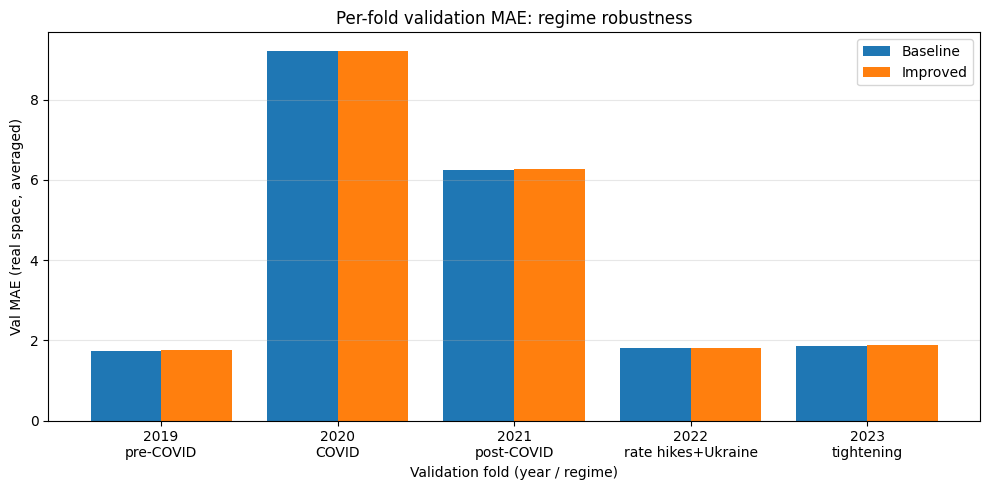

In [12]:
# Per-fold validation MAE (regime robustness): Baseline vs Improved
def eval_folds_per_target(params, is_improved, loss_type='l1'):
    folds_local = folds_mtl_imp if is_improved else folds_mtl
    val_years, maes = [], []
    for (mtl_tr, mtl_va, vy, fi) in folds_local:
        if is_improved:
            fold_scaler = make_robust_scaler(mtl_tr, selected_indices)
            train_ds = ImprovedYoYDatasetMTL(mtl_tr, fold_scaler, selected_indices)
            val_ds = ImprovedYoYDatasetMTL(mtl_va, fold_scaler, selected_indices)
            collate = collate_fn_improved_mtl
            model = ImprovedShallowLSTM(len(selected_indices), params['hidden_size'], len(PREDICTION_TARGETS), params.get('dropout',0.2), static_dim=STATIC_DIM).to(DEVICE)
        else:
            fold_scaler = make_scaler(mtl_tr)
            train_ds = YoYSequenceDatasetMTL(mtl_tr, max_seq_length, fold_scaler)
            val_ds = YoYSequenceDatasetMTL(mtl_va, max_seq_length, fold_scaler)
            collate = None
            model = ShallowLSTMClassifier(len(feature_cols), params['hidden_size'], len(PREDICTION_TARGETS), params.get('dropout',0.2), static_dim=STATIC_DIM).to(DEVICE)
        if collate:
            tr_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, collate_fn=collate)
            va_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate)
        else:
            tr_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
            va_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)
        opt = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        _, best_metric = train_and_eval(model, tr_loader, va_loader, opt, is_improved=is_improved, loss_type=loss_type, huber_delta=params.get('huber_delta',1.0))
        val_years.append(vy); maes.append(best_metric)
    return val_years, maes

base_params = best_mtl_baselines.get('l1', best_mtl_baselines)
imp_params = best_mtl_imp.get('l1', best_mtl_imp)
by, bm = eval_folds_per_target(base_params, is_improved=False)
iy, im = eval_folds_per_target(imp_params, is_improved=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(by))
w = 0.4
regime_tag = {2019:'pre-COVID', 2020:'COVID', 2021:'post-COVID', 2022:'rate hikes+Ukraine', 2023:'tightening'}
labels = [f"{y}\n{regime_tag.get(y,'')}" for y in by]
ax.bar(x - w/2, bm, width=w, label='Baseline')
ax.bar(x + w/2, im, width=w, label='Improved')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel('Validation fold (year / regime)')
ax.set_ylabel('Val MAE (real space, averaged)')
ax.set_title('Per-fold validation MAE: regime robustness')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


In [13]:
def build_loaders_and_model(is_improved, params):
    dropout_val = params.get("dropout", 0.2)
    if is_improved:
        train_ds = ImprovedYoYDatasetMTL(mtl_train_data_imp, robust_scaler, selected_indices)
        val_ds = ImprovedYoYDatasetMTL(mtl_val_data_imp, robust_scaler, selected_indices)
        test_ds = ImprovedYoYDatasetMTL(mtl_test_data_imp, robust_scaler, selected_indices)
        collate = collate_fn_improved_mtl
        model = ImprovedShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)
    else:
        train_ds = YoYSequenceDatasetMTL(mtl_train_data, max_seq_length, scaler)
        val_ds = YoYSequenceDatasetMTL(mtl_val_data, max_seq_length, scaler)
        test_ds = YoYSequenceDatasetMTL(mtl_test_data, max_seq_length, scaler)
        collate = None
        model = ShallowLSTMClassifier(len(feature_cols), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)

    if collate:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
    else:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False)

    return model, train_loader, val_loader, test_loader


def evaluate_loader(model, loader, is_improved):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            else:
                bx, bstatic, by, bmask = batch
                logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    if is_improved:
        y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
        y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res


def final_train_and_test(is_improved, params, loss_type='l1'):
    model, train_loader, val_loader, test_loader = build_loaders_and_model(
        is_improved, params
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    huber_delta = params.get("huber_delta", 1.0)

    model, _ = train_and_eval(
        model, train_loader, val_loader, optimizer,
        is_improved=is_improved, loss_type=loss_type, huber_delta=huber_delta
    )

    return evaluate_loader(model, test_loader, is_improved=is_improved)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

N_RUNS = 20
print(f"Computing Final Test Metrics using Test Sets across {N_RUNS} runs...")
final_results = []

def run_multiple_times(pipeline_name, is_improved, best_params_dict):
    for l_type, params in best_params_dict.items():
        print(f"Running {pipeline_name} with {l_type.upper()} loss...")
        target_results = {t: [] for t in list(PREDICTION_TARGETS) + ["Overall"]}
        for run_idx in range(N_RUNS):
            set_seed(SEED + run_idx)
            res = final_train_and_test(is_improved, params, loss_type=l_type)
            for target, val in res.items():
                target_results[target].append(val)

        for target in list(PREDICTION_TARGETS) + ["Overall"]:
            if len(target_results[target]) == 0:
                continue
            avg_mae = np.mean(target_results[target])
            std_mae = np.std(target_results[target])
            final_results.append({
                "Pipeline": pipeline_name,
                "Loss": l_type.upper(),
                "Target": target,
                "Test MAE (Mean)": avg_mae,
                "Deviation": std_mae
            })

Computing Final Test Metrics using Test Sets across 20 runs...


In [14]:
final_results = []
run_multiple_times("Baseline", False, best_mtl_baselines)
run_multiple_times("Improved", True, best_mtl_imp)

df_final = pd.DataFrame(final_results)

pivot_df = df_final.pivot_table(
    index=["Target", "Loss"],
    columns=["Pipeline"],
    values=["Test MAE (Mean)", "Deviation"]
)
display(pivot_df)

Running Baseline with L1 loss...
Running Improved with L1 loss...


Deviation           Test MAE (Mean)          
Pipeline         Baseline  Improved        Baseline  Improved
Target     Loss                                              
EBITDA     L1    0.011623  0.011887        0.881984  0.882265
Net_Income L1    0.011413  0.013707        0.953755  0.957352
Overall    L1    0.007440  0.009453        0.930327  0.931877
ROA        L1    0.006963  0.010561        0.954948  0.955711

## Overfitting Analysis (L1 Loss)

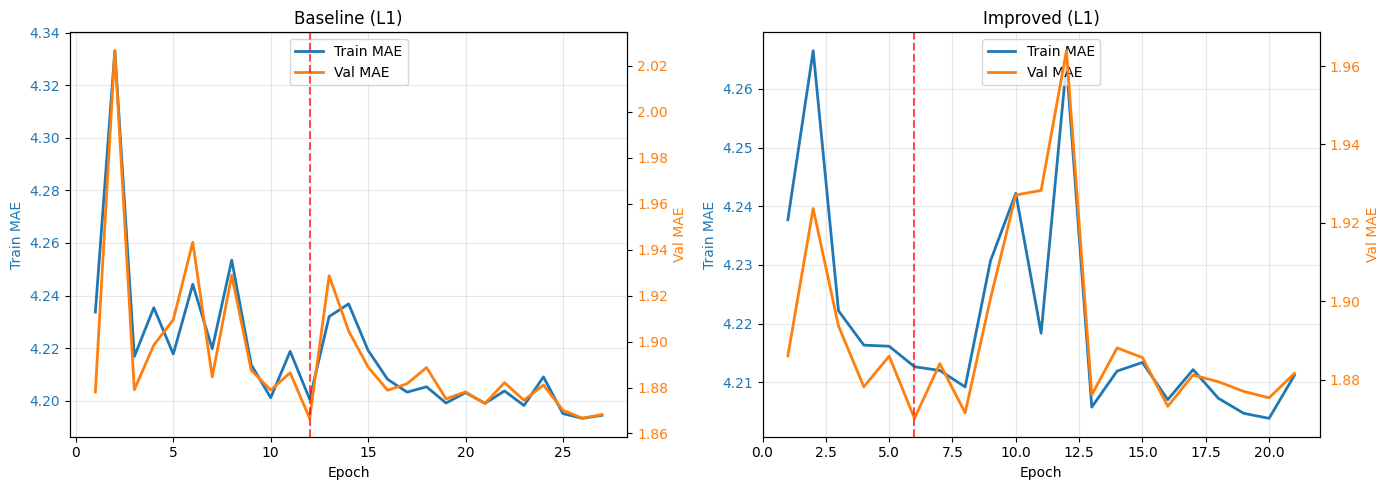

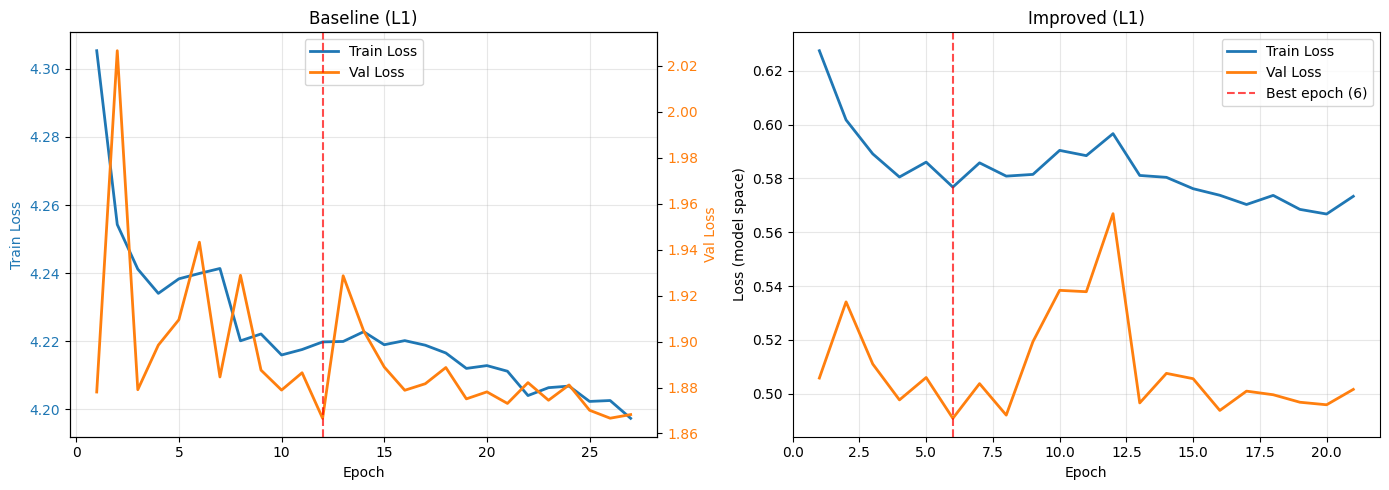

Baseline: 27 epochs, final train MAE=4.1944, final val MAE=1.8682 | final train loss=4.1974, final val loss=1.8682
Improved: 21 epochs, final train MAE=4.2112, final val MAE=1.8815 | final train loss=0.5734, final val loss=0.5016


In [15]:
def train_and_eval_with_history(model, train_loader, val_loader, optimizer, is_improved):
    criterion = nn.L1Loss(reduction='none')
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_state = None
    best_metric = float("inf")
    epochs_without_improvement = 0

    history = {"train_mae": [], "val_mae": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        # --- Training step ---
        model.train()
        epoch_loss_sum = 0.0
        epoch_loss_count = 0
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, lengths, bstatic)
                loss_m = criterion(logits, by)
                mask_f = bmask.to(loss_m.dtype)
                loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
                epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
                epoch_loss_count += int(bmask.sum().item())
            else:
                bx, bstatic, by, bmask = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, bstatic)
                loss_m = criterion(logits, by)
                mask_f = bmask.to(loss_m.dtype)
                loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
                epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
                epoch_loss_count += int(bmask.sum().item())

            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))

        # --- Eval-mode MAE on train set ---
        model.eval()
        def compute_mae(loader):
            all_preds, all_targets, all_masks = [], [], []
            with torch.no_grad():
                for batch in loader:
                    if is_improved:
                        bx, by, bmask, bstatic, lengths = batch
                        bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, lengths, bstatic)
                    else:
                        bx, bstatic, by, bmask = batch
                        bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, bstatic)
                    all_preds.append(logits.cpu().numpy())
                    all_targets.append(by.numpy())
                    all_masks.append(bmask.numpy() if not is_improved else bmask.numpy())
            if not all_preds:
                return None
            y_pred = np.vstack(all_preds)
            y_true = np.vstack(all_targets)
            mask = np.vstack(all_masks).astype(bool)
            abs_err = np.abs(y_pred - y_true)
            if is_improved:
                y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
                y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
                abs_err = np.abs(y_pred - y_true)
            return np.mean(abs_err[mask]) if mask.any() else 0.0

        def compute_loss(loader):
            total, count = 0.0, 0
            with torch.no_grad():
                for batch in loader:
                    if is_improved:
                        bx, by, bmask, bstatic, lengths = batch
                        bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, lengths, bstatic)
                    else:
                        bx, bstatic, by, bmask = batch
                        bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, bstatic)
                    loss_m = criterion(logits, by)
                    mask_bool = bmask.bool()
                    if mask_bool.any():
                        total += loss_m[mask_bool].sum().item()
                        count += int(mask_bool.sum().item())
            return total / max(count, 1) if count > 0 else None

        train_mae = compute_mae(train_loader)
        val_mae = compute_mae(val_loader)
        val_loss = compute_loss(val_loader)
        if train_mae is None or val_mae is None or val_loss is None:
            break

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["val_loss"].append(val_loss)

        scheduler.step(val_mae)

        improved = val_mae < best_metric
        if improved:
            best_metric = val_mae
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric, history


best_l1_base = best_mtl_baselines["l1"]
best_l1_imp = best_mtl_imp["l1"]

set_seed(SEED)
model_base, train_loader_base, val_loader_base, _ = build_loaders_and_model(False, best_l1_base)
optimizer_base = torch.optim.Adam(model_base.parameters(), lr=best_l1_base["lr"], weight_decay=best_l1_base["weight_decay"])
_, _, hist_base = train_and_eval_with_history(model_base, train_loader_base, val_loader_base, optimizer_base, is_improved=False)

set_seed(SEED)
model_imp, train_loader_imp, val_loader_imp, _ = build_loaders_and_model(True, best_l1_imp)
optimizer_imp = torch.optim.Adam(model_imp.parameters(), lr=best_l1_imp["lr"], weight_decay=best_l1_imp["weight_decay"])
_, _, hist_imp = train_and_eval_with_history(model_imp, train_loader_imp, val_loader_imp, optimizer_imp, is_improved=True)

# --- MAE Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for primary_ax, (title, hist) in zip(axes, [("Baseline (L1)", hist_base), ("Improved (L1)", hist_imp)]):
    epochs_range = range(1, len(hist["train_mae"]) + 1)

    # Configure primary axis for Train MAE
    train_color = 'tab:blue'
    primary_ax.set_xlabel("Epoch")
    primary_ax.set_ylabel("Train MAE", color=train_color)
    train_line = primary_ax.plot(epochs_range, hist["train_mae"], color=train_color, label="Train MAE", linewidth=2)
    primary_ax.tick_params(axis='y', labelcolor=train_color)

    # Create a secondary axis sharing the same x-axis
    secondary_ax = primary_ax.twinx()
    val_color = 'tab:orange'
    secondary_ax.set_ylabel("Val MAE", color=val_color)
    val_line = secondary_ax.plot(epochs_range, hist["val_mae"], color=val_color, label="Val MAE", linewidth=2)
    secondary_ax.tick_params(axis='y', labelcolor=val_color)

    # Mark the best epoch on the secondary axis (since it relates to Val MAE)
    best_epoch_idx = np.argmin(hist["val_mae"]) + 1
    secondary_ax.axvline(x=best_epoch_idx, color='red', linestyle='--', alpha=0.7)

    # Combine legends from both axes
    all_lines = train_line + val_line
    all_labels = [line.get_label() for line in all_lines]
    primary_ax.legend(all_lines, all_labels, loc='upper center')

    # Set title keeping only the main string
    primary_ax.set_title(title)
    primary_ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Loss curves (train vs val, model output space) ---
fig_loss, axes_loss = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, hist, use_twin) in zip(axes_loss, [("Baseline (L1)", hist_base, True), ("Improved (L1)", hist_imp, False)]):
    epochs_range = range(1, len(hist["train_loss"]) + 1)

    if use_twin:
        train_color = 'tab:blue'
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Train Loss", color=train_color)
        train_line = ax.plot(epochs_range, hist["train_loss"], color=train_color, label="Train Loss", linewidth=2)
        ax.tick_params(axis='y', labelcolor=train_color)

        secondary_ax = ax.twinx()
        val_color = 'tab:orange'
        secondary_ax.set_ylabel("Val Loss", color=val_color)
        val_line = secondary_ax.plot(epochs_range, hist["val_loss"], color=val_color, label="Val Loss", linewidth=2)
        secondary_ax.tick_params(axis='y', labelcolor=val_color)

        best_epoch_idx = np.argmin(hist["val_mae"]) + 1
        secondary_ax.axvline(x=best_epoch_idx, color='red', linestyle='--', alpha=0.7)

        all_lines = train_line + val_line
        all_labels = [line.get_label() for line in all_lines]
        ax.legend(all_lines, all_labels, loc='upper center')

        # Set title keeping only the main string
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
    else:
        ax.plot(epochs_range, hist["train_loss"], label="Train Loss", linewidth=2)
        ax.plot(epochs_range, hist["val_loss"], label="Val Loss", linewidth=2)
        best_epoch = np.argmin(hist["val_mae"]) + 1
        ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch})")

        # Set title keeping only the main string
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss (model space)")
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# E infine, la stampa dei risultati testuali
print(f"Baseline: {len(hist_base['train_mae'])} epochs, final train MAE={hist_base['train_mae'][-1]:.4f}, final val MAE={hist_base['val_mae'][-1]:.4f} | final train loss={hist_base['train_loss'][-1]:.4f}, final val loss={hist_base['val_loss'][-1]:.4f}")
print(f"Improved: {len(hist_imp['train_mae'])} epochs, final train MAE={hist_imp['train_mae'][-1]:.4f}, final val MAE={hist_imp['val_mae'][-1]:.4f} | final train loss={hist_imp['train_loss'][-1]:.4f}, final val loss={hist_imp['val_loss'][-1]:.4f}")

## Segmented Performance Analysis

In [16]:
def evaluate_group_pipeline(is_improved, best_params_dict):
    group_results = []

    for l_type, params in best_params_dict.items():
        # Store individual run MAEs here to compute standard deviation
        group_run_maes = {grp: {t: [] for t in PREDICTION_TARGETS} for grp in ticker_groups.keys()}

        for run_idx in range(N_RUNS):
            set_seed(SEED + run_idx)
            # Re-train model for this run
            model, train_loader, val_loader, _ = build_loaders_and_model(is_improved, params)
            optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
            huber_delta = params.get("huber_delta", 1.0)
            model, _ = train_and_eval(model, train_loader, val_loader, optimizer, is_improved=is_improved, loss_type=l_type, huber_delta=huber_delta)

            for group_name, tickers in ticker_groups.items():
                if is_improved:
                    group_df = mtl_test_data_imp[mtl_test_data_imp['company'].isin(tickers)]
                    if group_df.empty: continue
                    group_ds = ImprovedYoYDatasetMTL(group_df, robust_scaler, selected_indices)
                    collate = collate_fn_improved_mtl
                else:
                    group_df = mtl_test_data[mtl_test_data['company'].isin(tickers)]
                    if group_df.empty: continue
                    group_ds = YoYSequenceDatasetMTL(group_df, max_seq_length, scaler)
                    collate = None

                loader = DataLoader(group_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
                metrics = evaluate_loader(model, loader, is_improved=is_improved)

                if metrics:
                    for target, val in metrics.items():
                        if target not in PREDICTION_TARGETS:
                            continue
                        group_run_maes[group_name][target].append(val)

        # Compute mean and std
        for group_name in ticker_groups.keys():
            for target in PREDICTION_TARGETS:
                if len(group_run_maes[group_name][target]) > 0:
                    maes = group_run_maes[group_name][target]
                    group_results.append({
                        "Loss": l_type.upper(),
                        "Group": group_name,
                        "Target": target,
                        "MAE (Mean)": np.mean(maes),
                        "Deviation": np.std(maes)
                    })

    return group_results

print("Evaluating Improved MTL across losses and groups...")
imp_group_stats = evaluate_group_pipeline(True, best_mtl_imp)

print("\nEvaluating Baseline MTL across losses and groups...")
base_group_stats = evaluate_group_pipeline(False, best_mtl_baselines)

df_imp_group = pd.DataFrame(imp_group_stats)
df_base_group = pd.DataFrame(base_group_stats)

if df_imp_group.empty and df_base_group.empty:
    print("\nWARNING: No grouped results. The global test set may not contain all ticker groups.")
    print("Consider using the dedicated per-group pipeline for Mid-cap and Small-cap analysis.")

print("\n--- Grouped MAE: Improved MTL ---")
if not df_imp_group.empty:
    display(df_imp_group.pivot_table(index=['Target', 'Loss'], columns='Group', values=['MAE (Mean)', 'Deviation']))
else:
    print("No data available for Improved MTL grouping.")

print("\n--- Grouped MAE: Baseline MTL ---")
if not df_base_group.empty:
    display(df_base_group.pivot_table(index=['Target', 'Loss'], columns='Group', values=['MAE (Mean)', 'Deviation']))
else:
    print("No data available for Baseline MTL grouping.")

Evaluating Improved MTL across losses and groups...

Evaluating Baseline MTL across losses and groups...

--- Grouped MAE: Improved MTL ---


Deviation                     MAE (Mean)                    
Group                 MIB   Mid-cap Small-cap        MIB   Mid-cap Small-cap
Target     Loss                                                             
EBITDA     L1    0.006908  0.016397  0.012789   0.310248  0.703970  1.215251
Net_Income L1    0.006420  0.023984  0.010705   0.388085  0.750934  1.303123
ROA        L1    0.009025  0.015972  0.008826   0.375039  0.584239  1.414886


--- Grouped MAE: Baseline MTL ---


Deviation                     MAE (Mean)                    
Group                 MIB   Mid-cap Small-cap        MIB   Mid-cap Small-cap
Target     Loss                                                             
EBITDA     L1    0.010498  0.014458  0.014949   0.316479  0.696885  1.217408
Net_Income L1    0.015429  0.021055  0.010190   0.389683  0.746341  1.298816
ROA        L1    0.011218  0.012632  0.007913   0.388837  0.578362  1.412568

## Directional Accuracy

In [17]:
def calculate_directional_accuracy(model, loader, is_improved):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                all_masks.append(bmask.numpy())
            else:
                bx, bstatic, by, bmask = batch
                logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
                all_masks.append(bmask.numpy())
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    mask = np.vstack(all_masks)

    accuracy_res = {}
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0: continue
        # Directional agreement: both positive or both negative
        correct_dir = (np.sign(y_pred[m, i]) == np.sign(y_true[m, i])).sum()
        accuracy_res[t] = correct_dir / m.sum()
    return accuracy_res

print("--- Directional Accuracy (Improved Pipeline) ---")
for l_type, params in best_mtl_imp.items():
    set_seed(SEED)
    model_imp, train_loader_imp, val_loader_imp, test_loader_imp = build_loaders_and_model(True, params)
    optimizer = torch.optim.Adam(model_imp.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    huber_delta = params.get("huber_delta", 1.0)
    model_imp, _ = train_and_eval(
        model_imp, train_loader_imp, val_loader_imp, optimizer,
        is_improved=True, loss_type=l_type, huber_delta=huber_delta
    )
    dir_acc = calculate_directional_accuracy(model_imp, test_loader_imp, True)
    print(f"[{l_type.upper()}] Directional Accuracy:", dir_acc)

--- Directional Accuracy (Improved Pipeline) ---
[L1] Directional Accuracy: {'EBITDA': np.float64(0.6441717791411042), 'Net_Income': np.float64(0.5365853658536586), 'ROA': np.float64(0.5792682926829268)}


## Specialized Models by Market Cap

In [18]:
def run_dedicated_pipeline(group_name, tickers, loss_type='l1'):
    print(f"\n--- Dedicated Pipeline: {group_name} ({loss_type.upper()}) ---")

    group_df = improved_data_df[improved_data_df['company'].isin(tickers)].copy()
    if group_df.empty:
        print(f"Skipping {group_name}: No data available.")
        return [], None

    try:
        g_folds, g_test = temporal_kfold_split(group_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)
    except ValueError as e:
        print(f"Skipping {group_name}: {e}")
        return [], None

    if g_test.equals(group_df) or len(g_folds) == 0:
        print(f"Skipping {group_name}: not enough folds/years.")
        return [], None

    g_folds_mtl = [(extract_mtl_df(tr), extract_mtl_df(va), vy, fi) for (tr, va, vy, fi) in g_folds]
    g_mtl_test = extract_mtl_df(g_test)

    fixed_window_size = None  # Use full 365-day lookback (no truncation)

    def group_objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)

        fold_metrics = []
        for (g_mtl_train, g_mtl_val, vy, fi) in g_folds_mtl:
            g_scaler = make_robust_scaler(g_mtl_train, selected_indices)
            train_ds = ImprovedYoYDatasetMTL(g_mtl_train, g_scaler, selected_indices, window_size=fixed_window_size)
            val_ds = ImprovedYoYDatasetMTL(g_mtl_val, g_scaler, selected_indices, window_size=fixed_window_size)
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)
            model = ImprovedShallowLSTM(
                input_size=len(selected_indices),
                hidden_size=hidden_size,
                num_targets=len(PREDICTION_TARGETS),
                dropout=dropout,
                static_dim=STATIC_DIM
            ).to(DEVICE)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            _, best_metric = train_and_eval(
                model=model, train_loader=train_loader, val_loader=val_loader,
                optimizer=optimizer, is_improved=True, trial=None, loss_type=loss_type
            )
            fold_metrics.append(best_metric)
            trial.report(float(np.mean(fold_metrics)), fi)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return float(np.mean(fold_metrics))

    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_imp_{group_name}", pruner=pruner)
    study.optimize(group_objective, n_trials=OPTUNA_TRIALS)

    best_params = study.best_trial.params
    print(f"Best Params for {group_name}: {best_params}\n")

    # Final retrain on the single split (largest fold) + test on held-out 2024
    g_train, g_val, _ = split_to_single(group_df, test_year_cutoff=TEST_YEAR_CUTOFF)
    g_scaler = make_robust_scaler(g_train, selected_indices)
    g_mtl_train = extract_mtl_df(g_train)
    g_mtl_val = extract_mtl_df(g_val)

    target_results = {t: [] for t in PREDICTION_TARGETS}

    for run_idx in range(N_RUNS):
        set_seed(SEED + run_idx)

        train_ds = ImprovedYoYDatasetMTL(g_mtl_train, g_scaler, selected_indices, window_size=fixed_window_size)
        val_ds = ImprovedYoYDatasetMTL(g_mtl_val, g_scaler, selected_indices, window_size=fixed_window_size)
        test_ds = ImprovedYoYDatasetMTL(g_mtl_test, g_scaler, selected_indices, window_size=fixed_window_size)

        train_loader = DataLoader(train_ds, batch_size=best_params["batch_size"], shuffle=True, collate_fn=collate_fn_improved_mtl)
        val_loader = DataLoader(val_ds, batch_size=best_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)
        test_loader = DataLoader(test_ds, batch_size=best_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)

        dropout_val = best_params.get("dropout", 0.2)

        model = ImprovedShallowLSTM(
            input_size=len(selected_indices),
            hidden_size=best_params["hidden_size"],
            num_targets=len(PREDICTION_TARGETS),
            dropout=dropout_val,
            static_dim=STATIC_DIM
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

        model, _ = train_and_eval(
            model=model, train_loader=train_loader, val_loader=val_loader,
            optimizer=optimizer, is_improved=True, trial=None, loss_type=loss_type
        )

        res = evaluate_loader(model, test_loader, True)

        if res:
            for target, val in res.items():
                if target not in PREDICTION_TARGETS:
                    continue
                target_results[target].append(val)

    group_stats = []

    for target in PREDICTION_TARGETS:
        if not target_results[target]:
            print(f"  NOTE: {target} has no valid data for {group_name}. Skipping.")
            continue

        avg_mae = np.mean(target_results[target])
        std_mae = np.std(target_results[target])

        group_stats.append({
            "Group": group_name,
            "Target": target,
            "Dedicated Test MAE": avg_mae,
            "Dedicated Deviation": std_mae
        })

    valid_means = [np.mean(target_results[t]) for t in PREDICTION_TARGETS if target_results[t]]
    if valid_means:
        total_mae = np.mean(valid_means)
        total_std = np.std(valid_means)

        print(f"{group_name} - Total Test MAE: {total_mae:.4f} ± {total_std:.4f}")

        group_stats.append({
            "Group": group_name,
            "Target": "TOTAL",
            "Dedicated Test MAE": total_mae,
            "Dedicated Deviation": total_std
        })

    return group_stats, best_params

dedicated_all_stats = []
dedicated_best_params = {}
for group_name, tickers in ticker_groups.items():
    stats, params = run_dedicated_pipeline(group_name, tickers, loss_type='l1')
    if params is not None:
        dedicated_best_params[group_name] = params
    if stats:
        dedicated_all_stats.extend(stats)

df_dedicated = pd.DataFrame(dedicated_all_stats)
pivot_result = df_dedicated.pivot(index='Target', columns='Group', values='Dedicated Test MAE')
print("\nNote: NaN indicates no valid data for that target/group combination.")
display(pivot_result.fillna("N/A"))



--- Dedicated Pipeline: MIB (L1) ---
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (87 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (596), val = 2019 (78)
  Fold 2: train <= 2019 (674), val = 2020 (84)
  Fold 3: train <= 2020 (758), val = 2021 (83)
  Fold 4: train <= 2021 (841), val = 2022 (83)
  Fold 5: train <= 2022 (924), val = 2023 (87)


[I 2026-06-29 01:53:38,164] A new study created in memory with name: mtl_imp_MIB
[I 2026-06-29 01:54:14,116] Trial 0 finished with value: 1.9912042617797852 and parameters: {'hidden_size': 64, 'lr': 0.0008178526250806987, 'batch_size': 32, 'weight_decay': 2.0884155990193177e-05, 'dropout': 0.40270105193060746}. Best is trial 0 with value: 1.9912042617797852.
[I 2026-06-29 01:54:41,348] Trial 1 finished with value: 1.9526246786117554 and parameters: {'hidden_size': 128, 'lr': 0.004526360601760511, 'batch_size': 64, 'weight_decay': 9.40455775459645e-05, 'dropout': 0.4877354270237877}. Best is trial 1 with value: 1.9526246786117554.
[I 2026-06-29 01:55:13,119] Trial 2 finished with value: 1.9563653469085693 and parameters: {'hidden_size': 256, 'lr': 0.005041776940516697, 'batch_size': 64, 'weight_decay': 3.1408424670796275e-06, 'dropout': 0.1883371913519688}. Best is trial 1 with value: 1.9526246786117554.
[I 2026-06-29 01:55:59,365] Trial 3 finished with value: 1.946988821029663 and para

Best Params for MIB: {'hidden_size': 64, 'lr': 0.007116567225443665, 'batch_size': 16, 'weight_decay': 1.3515637279527326e-05, 'dropout': 0.27556862876041277}

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (87 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (924), val = 2023 (87)
MIB - Total Test MAE: 0.3817 ± 0.0493

--- Dedicated Pipeline: Mid-cap (L1) ---
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (159 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (906), val = 2019 (130)
  Fold 2: train <= 2019 (1036), val = 2020 (138)
  Fold 3: train <= 2020 (1174), val = 2021 (141)
  Fold 4: train <= 2021 (1315), val = 2022 (153)
  Fold 5: train <= 2022 (1468), val = 2023 (156)


[I 2026-06-29 02:14:04,246] A new study created in memory with name: mtl_imp_Mid-cap
[I 2026-06-29 02:14:50,636] Trial 0 finished with value: 1.3556655645370483 and parameters: {'hidden_size': 256, 'lr': 0.0012074482025307362, 'batch_size': 32, 'weight_decay': 3.8139693641246312e-06, 'dropout': 0.38467931342769346}. Best is trial 0 with value: 1.3556655645370483.
[I 2026-06-29 02:15:40,282] Trial 1 finished with value: 1.3518199920654297 and parameters: {'hidden_size': 64, 'lr': 0.003680027440995135, 'batch_size': 32, 'weight_decay': 0.0006321786968135235, 'dropout': 0.12199828854997721}. Best is trial 1 with value: 1.3518199920654297.
[I 2026-06-29 02:16:35,719] Trial 2 finished with value: 1.361509919166565 and parameters: {'hidden_size': 256, 'lr': 0.0004443411243565317, 'batch_size': 16, 'weight_decay': 0.000410906298940261, 'dropout': 0.17171108358312118}. Best is trial 1 with value: 1.3518199920654297.
[I 2026-06-29 02:17:08,050] Trial 3 finished with value: 1.3569105863571167 an

Best Params for Mid-cap: {'hidden_size': 128, 'lr': 0.007092621060168155, 'batch_size': 16, 'weight_decay': 2.5697021532876645e-06, 'dropout': 0.2901844961410098}

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (159 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (1468), val = 2023 (156)
Mid-cap - Total Test MAE: 0.6765 ± 0.0692

--- Dedicated Pipeline: Small-cap (L1) ---
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (242 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (1551), val = 2019 (210)
  Fold 2: train <= 2019 (1761), val = 2020 (222)
  Fold 3: train <= 2020 (1983), val = 2021 (228)
  Fold 4: train <= 2021 (2211), val = 2022 (235)
  Fold 5: train <= 2022 (2446), val = 2023 (243)


[I 2026-06-29 02:43:50,557] A new study created in memory with name: mtl_imp_Small-cap
[I 2026-06-29 02:45:20,024] Trial 0 finished with value: 6.793883323669434 and parameters: {'hidden_size': 64, 'lr': 0.00011039188731014561, 'batch_size': 64, 'weight_decay': 1.090217871481878e-06, 'dropout': 0.26604403127433685}. Best is trial 0 with value: 6.793883323669434.
[I 2026-06-29 02:46:29,543] Trial 1 finished with value: 6.7637224197387695 and parameters: {'hidden_size': 256, 'lr': 0.0006222458976258606, 'batch_size': 64, 'weight_decay': 7.22345232412856e-05, 'dropout': 0.3054351559847506}. Best is trial 1 with value: 6.7637224197387695.
[I 2026-06-29 02:47:39,956] Trial 2 finished with value: 6.759320259094238 and parameters: {'hidden_size': 256, 'lr': 0.0020251693700783094, 'batch_size': 64, 'weight_decay': 3.1753933380049756e-05, 'dropout': 0.11554706923973397}. Best is trial 2 with value: 6.759320259094238.
[I 2026-06-29 02:49:20,364] Trial 3 finished with value: 6.764482021331787 and

Best Params for Small-cap: {'hidden_size': 32, 'lr': 0.009957348364262163, 'batch_size': 16, 'weight_decay': 4.6570184954228925e-06, 'dropout': 0.16647494103625282}

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (242 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (2446), val = 2023 (243)
Small-cap - Total Test MAE: 1.3138 ± 0.0836

Note: NaN indicates no valid data for that target/group combination.


Group,MIB,Mid-cap,Small-cap
Target,,,
EBITDA,0.312468,0.706272,1.217057
Net_Income,0.409434,0.742464,1.303373
ROA,0.423311,0.580903,1.421088
TOTAL,0.381737,0.676546,1.313839


In [19]:
results = []
fixed_window_size = None  # Use full 365-day lookback (no truncation)

for group_name, tickers in ticker_groups.items():

    print("\n" + "=" * 60)
    print(f"Training Final Model for: {group_name}")
    print("=" * 60)

    params = dedicated_best_params[group_name]

    set_seed(42)

    group_df = improved_data_df[
        improved_data_df["company"].isin(tickers)
    ].copy()

    if group_df.empty:
        print(f"Skipping {group_name}: No data available.")
        continue

    # Single-split (largest fold) for final training + held-out 2024 test
    try:
        g_train, g_val, g_test = split_to_single(group_df, test_year_cutoff=TEST_YEAR_CUTOFF)
    except ValueError as e:
        print(f"Skipping {group_name}: {e}")
        continue

    if g_train.empty:
        print(f"Skipping {group_name}: Training set is empty.")
        continue

    g_scaler = RobustScaler()

    train_windows = np.vstack([
        row[:, selected_indices]
        for row in g_train["window_data"]
    ])

    g_scaler.fit(train_windows)

    # Pass fixed_window_size to avoid the TypeError
    train_ds = ImprovedYoYDatasetMTL(
        extract_mtl_df(g_train),
        g_scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    val_ds = ImprovedYoYDatasetMTL(
        extract_mtl_df(g_val),
        g_scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    test_ds = ImprovedYoYDatasetMTL(
        extract_mtl_df(g_test),
        g_scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=params["batch_size"],
        shuffle=True,
        collate_fn=collate_fn_improved_mtl
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=params["batch_size"],
        shuffle=False,
        collate_fn=collate_fn_improved_mtl
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=params["batch_size"],
        shuffle=False,
        collate_fn=collate_fn_improved_mtl
    )

    # Initialize the single-layer architecture
    model = ImprovedShallowLSTM(
        input_size=len(selected_indices),
        hidden_size=params["hidden_size"],
        num_targets=len(PREDICTION_TARGETS),
        dropout=params["dropout"],
        static_dim=STATIC_DIM
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    model, _ = train_and_eval(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        is_improved=True,
        trial=None,
        loss_type='l1'
    )

    print(f"\nTEST RESULTS FOR {group_name}")
    mae, rmse = evaluate_real_metrics(
        model,
        test_loader,
        DEVICE
    )

    n_samples = len(test_ds)

    results.append({
        "Group": group_name,
        "MAE": mae,
        "RMSE": rmse,
        "N": n_samples
    })

df_results = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(df_results)

# Safely calculate weighted metrics only if we have results
if not df_results.empty and df_results["N"].sum() > 0:
    weighted_mae = (
        (df_results["MAE"] * df_results["N"]).sum()
        / df_results["N"].sum()
    )

    weighted_rmse = (
        (df_results["RMSE"] * df_results["N"]).sum()
        / df_results["N"].sum()
    )

    print(f"\nWeighted MAE: {weighted_mae:.4f}")
    print(f"Weighted RMSE: {weighted_rmse:.4f}")
else:
    print("\nNo valid results to compute weighted metrics.")



Training Final Model for: MIB
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (87 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (924), val = 2023 (87)

TEST RESULTS FOR MIB
Test MAE  (Real Scale): 0.3841
Test RMSE (Real Scale): 0.6201

Training Final Model for: Mid-cap
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (159 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (1468), val = 2023 (156)

TEST RESULTS FOR Mid-cap
Test MAE  (Real Scale): 0.6941
Test RMSE (Real Scale): 2.2655

Training Final Model for: Small-cap
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test: > 2023 (242 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  F